## Overall classification: disturbed vs undisturbed

In [7]:
import numpy as np
import pandas as pd
from pathlib import Path
from scipy.signal import detrend, spectrogram
import random
import matplotlib.pyplot as plt

In [8]:
def load_and_interpolate(file):

    # Read only the measurement table
    df = pd.read_csv(
        file,
        sep="\t",
        skiprows=1,
        names=["power", "time"],
        engine="python"
    )

    # Remove footer rows
    df = df[pd.to_numeric(df["power"], errors="coerce").notna()]
    
    df["power"] = pd.to_numeric(df["power"], errors="coerce")
    df["time"] = pd.to_numeric(df["time"], errors="coerce")

    df = df.dropna()

    t = df["time"].to_numpy()
    signal = df["power"].to_numpy()

    # Average sampling interval
    dt = np.mean(np.diff(t))

    # Uniform time grid
    t_uniform = np.arange(t[0], t[-1], dt)

    # Interpolate
    signal_uniform = np.interp(
        t_uniform,
        t,
        signal
    )

    # Remove mean / drift
    signal_uniform = detrend(signal_uniform)

    return t_uniform, signal_uniform

In [9]:
def process_folder(folder):

    X = []

    for file in Path(folder).glob("*.txt"):

        t, signal = load_and_interpolate(file)

        fft_features = np.abs(np.fft.rfft(signal))[1:150]

        if len(fft_features) != 149:
            print(f"Warning: {file} produced {len(fft_features)} bins")

        X.append(fft_features)

    return np.array(X)

In [10]:
X_disturb = process_folder("Saved data/1_disturbed")
X_undisturb = process_folder("Saved data/0_undisturbed")

c:\Users\leach\miniforge3\Lib\site-packages\numpy\core\fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\leach\miniforge3\Lib\site-packages\numpy\core\_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


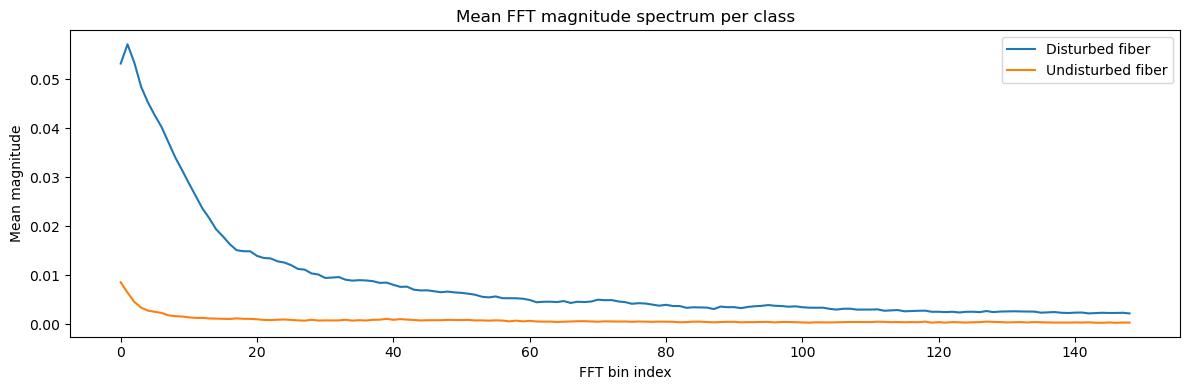

In [11]:
freqs = np.fft.rfftfreq(150, d=np.mean([np.mean(np.diff(t)) for t in []]))  # approximate

plt.figure(figsize=(12, 4))
plt.plot(np.log1p(X_disturb.mean(axis=0)), label="Disturbed fiber")
plt.plot(np.log1p(X_undisturb.mean(axis=0)), label="Undisturbed fiber")
plt.xlabel("FFT bin index")
plt.ylabel("Mean magnitude")
plt.title("Mean FFT magnitude spectrum per class")
plt.legend()
plt.tight_layout()
plt.show()

In [12]:
def plot_spectrograms(folder, label, n=3):
    all_files = list(Path(folder).glob("*.txt"))
    files = random.sample(all_files, min(n, len(all_files)))
    fig, axes = plt.subplots(1, n, figsize=(5*n, 4))
    
    for ax, file in zip(axes, files):
        t, signal = load_and_interpolate(file)
        dt = np.mean(np.diff(t))
        fs = 1 / dt
        
        f, tt, Sxx = spectrogram(signal, fs=fs, nperseg=64, noverlap=32)
        ax.pcolormesh(tt, f, 10*np.log10(Sxx + 1e-10), cmap="viridis")
        ax.set_xlabel("Time [s]")
        ax.set_ylabel("Frequency [Hz]")
        ax.set_title(f"{label} — {file.name}")
    
    plt.suptitle(f"Spectrograms: {label}")
    plt.tight_layout()
    plt.show()

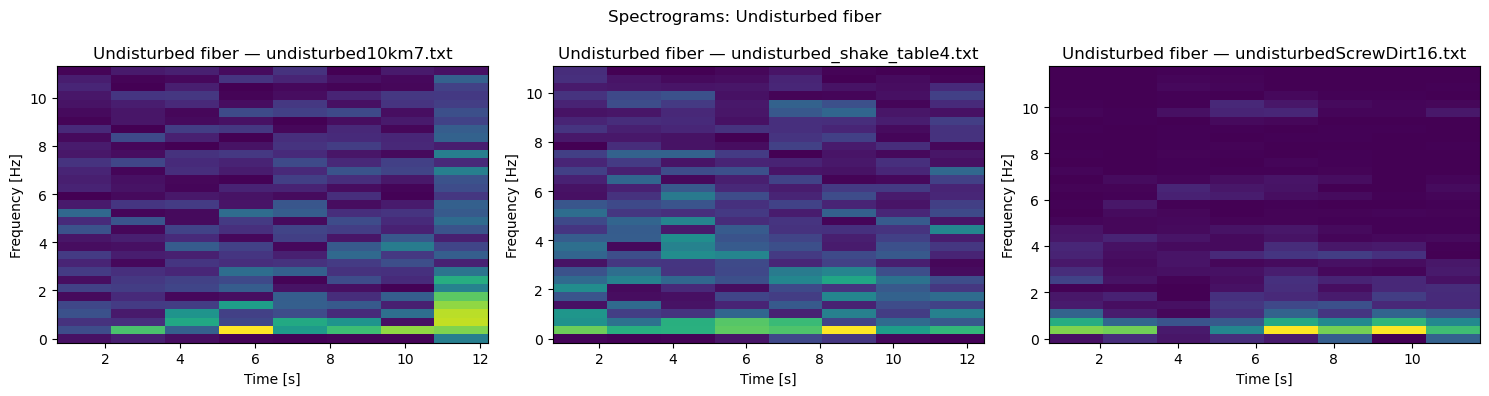

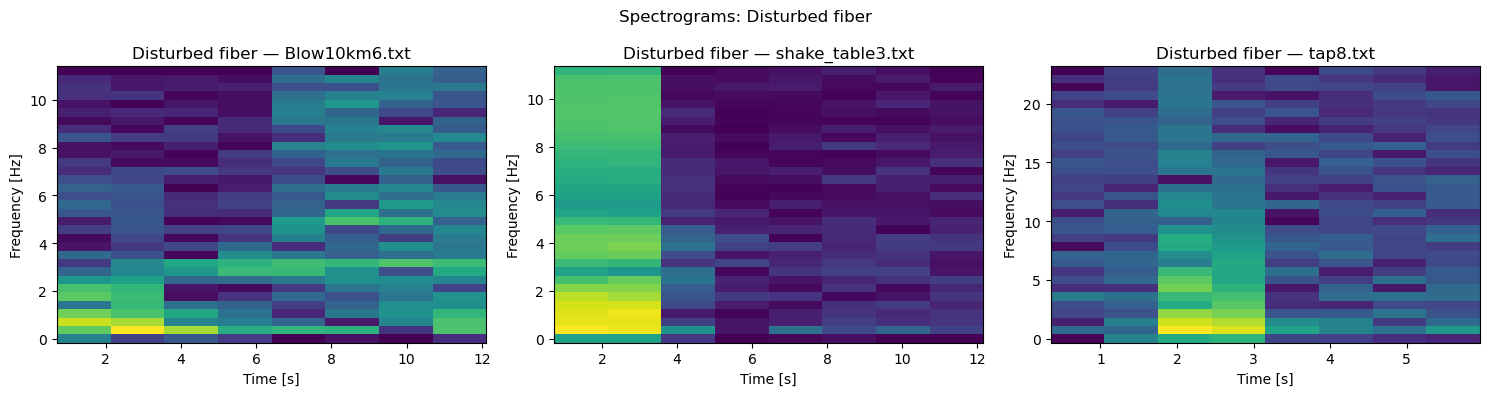

In [27]:
plot_spectrograms("Saved data/0_undisturbed", "Undisturbed fiber")
plot_spectrograms("Saved data/1_disturbed", "Disturbed fiber")

### Random Forest classification

In [14]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_val_score

In [15]:
X = np.vstack([X_disturb, X_undisturb])

y = np.concatenate([
    np.ones(len(X_disturb)),   # 1 = disturbed
    np.zeros(len(X_undisturb)) # 0 = undisturbed
])

              precision    recall  f1-score   support

   Disturbed       0.82      0.86      0.84        21
 Undisturbed       0.82      0.78      0.80        18

    accuracy                           0.82        39
   macro avg       0.82      0.82      0.82        39
weighted avg       0.82      0.82      0.82        39



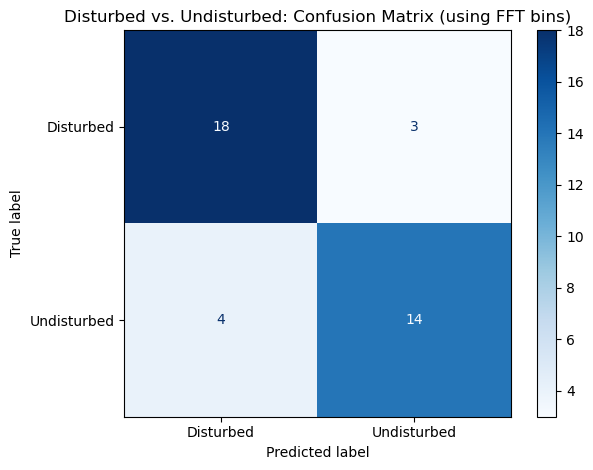

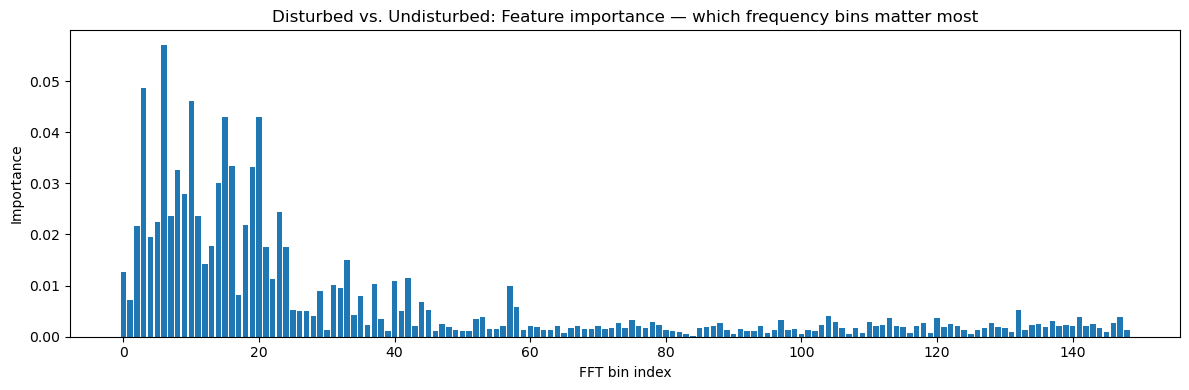

In [16]:
# Split into train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y
)

# Train
clf = RandomForestClassifier(n_estimators=200)
clf.fit(X_train, y_train)

# Evaluate
y_pred = clf.predict(X_test)
print(classification_report(y_test, y_pred, target_names=["Disturbed", "Undisturbed"]))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=["Disturbed", "Undisturbed"])
disp.plot(cmap="Blues")
plt.title("Disturbed vs. Undisturbed: Confusion Matrix (using FFT bins)")
plt.tight_layout()
#plt.savefig("confusion_matrix_.png", dpi=150)
plt.show()

# Feature importance
importances = clf.feature_importances_
plt.figure(figsize=(12, 4))
plt.bar(range(len(importances)), importances)
plt.xlabel("FFT bin index")
plt.ylabel("Importance")
plt.title("Disturbed vs. Undisturbed: Feature importance — which frequency bins matter most")
plt.tight_layout()
#plt.savefig("feature_importance_.png", dpi=150)
plt.show()

In [17]:
cv_scores = cross_val_score(clf, X, y, cv=5, scoring="accuracy")
print(f"Cross-validation accuracy: {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")
print(f"Individual folds: {cv_scores}")

Cross-validation accuracy: 0.787 ± 0.133
Individual folds: [0.84615385 0.87179487 0.69230769 0.57894737 0.94736842]


## Feature Engineering to improve model

In [29]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_val_score
from scipy.signal import find_peaks
from scipy.stats import kurtosis

In [ ]:
from pyexpat import features


def extract_features(signal, fs):
    features = {}
    
    # looks at power values, not fft bins
    features["total_energy"] = np.sum(signal**2) # sums the samples and squares them, tells how much signal deviated from 0
    features["peak_magnitude"] = np.max(np.abs(signal)) # gives largest fluctuation
    features["root_mean_square"] = np.sqrt(np.mean(signal**2)) # measures the average power
    
    # Now looks at frequency and fft bins
    freqs = np.fft.rfftfreq(len(signal), d=1/fs)
    fft_mag = np.abs(np.fft.rfft(signal))
    
    # energy concentrated at low frequency is not present when undisturbed, the noise is more spread 
    low  = (freqs >= 0) & (freqs < 2)
    energy_low  = np.sum(fft_mag[low]**2)
    features["energy_low"] = energy_low
    
    # How much does the signal exceed its own noise floor?
    noise_floor = np.std(signal)
    features["peak_to_noise"] = np.max(np.abs(signal)) / (noise_floor + 1e-10)
    
    # What fraction of the signal is above a noise threshold?
    # Undisturbed = almost nothing above threshold, disturbed = clear burst above it
    threshold = 3 * np.std(signal)
    features["fraction_above_threshold"] = np.sum(np.abs(signal) > threshold) / len(signal)

    # How variable is the signal energy over time?
    # Undisturbed = flat and consistent, disturbed = one big spike then quiet
    energy_envelope = signal**2
    features["energy_std"] = np.std(energy_envelope)
    features["energy_max_to_mean"] = np.max(energy_envelope) / (np.mean(energy_envelope) + 1e-10)

    # Kurtosis measures how "peaky" the distribution of values is
    # Undisturbed = gaussian noise (kurtosis ~3), disturbed = sharp spike (kurtosis >> 3)
    features["kurtosis"] = kurtosis(signal)
    
    return features 

In [44]:
def process_folder_features(folder):
    rows = []
    for file in Path(folder).glob("*.txt"):
        if file.name.lower().startswith("readme"):
            continue
        try:
            t, signal = load_and_interpolate(file)
            dt = np.mean(np.diff(t))
            fs = 1 / dt
            feats = extract_features(signal, fs)
            rows.append(feats)
        except Exception as e:
            print(f"FAILED: {file.name} — {e}")

    return pd.DataFrame(rows)  # each row = one file, each column = one feature

In [45]:
df_disturb  = process_folder_features("Saved data/1_disturbed")
df_undisturb = process_folder_features("Saved data/0_undisturbed")
                                       
df_disturb["label"] = 0
df_undisturb["label"]  = 1

df_all = pd.concat([df_disturb, df_undisturb], ignore_index=True)

X = df_all.drop(columns="label").values
y = df_all["label"].values

              precision    recall  f1-score   support

   disturbed       0.80      0.89      0.84        18
 undisturbed       0.89      0.81      0.85        21

    accuracy                           0.85        39
   macro avg       0.85      0.85      0.85        39
weighted avg       0.85      0.85      0.85        39



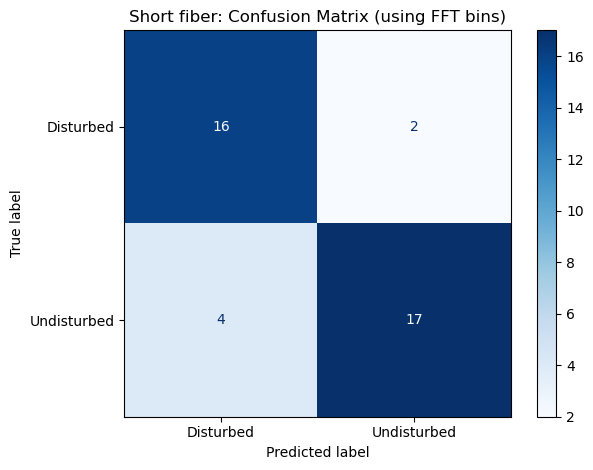

In [46]:
# Then identical to before
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y)

clf = RandomForestClassifier(n_estimators=200)
clf.fit(X_train, y_train)

# Evaluate
y_pred = clf.predict(X_test)
print(classification_report(y_test, y_pred, target_names=["disturbed", "undisturbed"]))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=["Disturbed", "Undisturbed"])
disp.plot(cmap="Blues")
plt.title("Short fiber: Confusion Matrix (using FFT bins)")
plt.tight_layout()
#plt.savefig("confusion_matrix4.png", dpi=150)
plt.show()

In [47]:
cv_scores = cross_val_score(clf, X, y, cv=5, scoring="accuracy")
print(f"Cross-validation accuracy: {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")
print(f"Individual folds: {cv_scores}")

Cross-validation accuracy: 0.788 ± 0.090
Individual folds: [0.82051282 0.74358974 0.69230769 0.73684211 0.94736842]


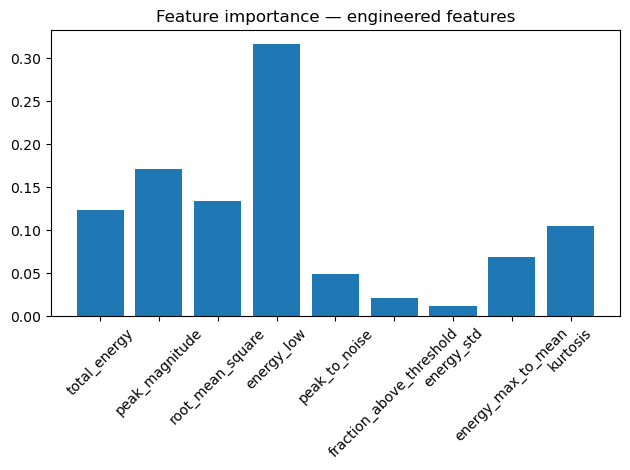

In [37]:
feature_names = df_all.drop(columns="label").columns
importances = clf.feature_importances_

plt.bar(feature_names, importances)
plt.xticks(rotation=45)
plt.title("Feature importance — engineered features")
plt.tight_layout()
plt.show()